# Capstone Project: Sales & Profit Analytics on Sample Superstore Data
**Course:** B.Com Business Analytics

**Sections:** 1) Context & problem statement  2) Data description & classification  3) Regression & Decision Tree  4) Time series analysis  5) Conclusion

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import os, warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
os.makedirs('figs', exist_ok=True)

df = pd.read_csv('Sample_-_Superstore.csv', encoding='latin1')   # change path if running on Kaggle/Colab
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])
print(df.shape)
df.head()

(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 1. Overview of Context / Data
**Business context:** Superstore is a US retailer selling Furniture, Office Supplies and Technology to Consumer, Corporate and Home Office customers across four regions. Management wants to know what drives profit and how sales will behave in coming months.

**Problem statement:** Which order-level factors (sales value, quantity, discount, category, segment, region, ship mode) drive *Profit*, and what will monthly *Sales* look like going forward?

**Target variables:** (a) `Profit` (continuous, for MLR); (b) `Profitable` = 1 if Profit > 0 else 0 (binary, for Logistic Regression and Decision Tree); (c) monthly `Sales` (for time series).

**Feature variables:** Sales, Quantity, Discount, Category, Segment, Region, Ship Mode.

In [2]:
df.info()
print('\nMissing values:', df.isna().sum().sum(), '| Duplicate rows:', df.duplicated().sum())
print('Date range:', df['Order Date'].min().date(), 'to', df['Order Date'].max().date())

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

## 2. Data Description & Classification

In [3]:
# Data classification: numerical (continuous / discrete) vs categorical (nominal / ordinal)
classification = pd.DataFrame({
 'Variable': ['Sales','Profit','Discount','Quantity','Category','Sub-Category','Segment','Region','Ship Mode','State/City','Order Date','Ship Date'],
 'Type': ['Numerical','Numerical','Numerical','Numerical','Categorical','Categorical','Categorical','Categorical','Categorical','Categorical','Date-time','Date-time'],
 'Sub-type': ['Continuous (ratio)','Continuous (ratio)','Continuous (ratio)','Discrete (ratio)','Nominal','Nominal','Nominal','Nominal','Ordinal','Nominal','Interval','Interval'],
 'Role': ['Feature','Target','Feature','Feature','Feature','-','Feature','Feature','Feature','-','Time series index','-']})
classification

,Variable,Type,Sub-type,Role
0,Sales,Numerical,Continuous (ratio),Feature
1,Profit,Numerical,Continuous (ratio),Target
2,Discount,Numerical,Continuous (ratio),Feature
3,Quantity,Numerical,Discrete (ratio),Feature
4,Category,Categorical,Nominal,Feature
5,Sub-Category,Categorical,Nominal,-
6,Segment,Categorical,Nominal,Feature
7,Region,Categorical,Nominal,Feature
8,Ship Mode,Categorical,Ordinal,Feature
9,State/City,Categorical,Nominal,-


In [4]:
num = ['Sales','Quantity','Discount','Profit']
desc = df[num].agg(['count','mean','median','std','var','min','max','skew']).T
desc['mode'] = [df[c].mode()[0] for c in num]
desc['CV %'] = desc['std']/desc['mean']*100
desc.round(3)

,count,mean,median,std,var,min,max,skew,mode,CV %
Sales,9994.0,229.858,54.490,623.245,388434.455,0.444,22638.480,12.973,12.96,271.144
Quantity,9994.0,3.790,3.000,2.225,4.951,1.000,14.000,1.279,3.00,58.717
Discount,9994.0,0.156,0.200,0.206,0.043,0.000,0.800,1.684,0.00,132.169
Profit,9994.0,28.657,8.666,234.260,54877.798,-6599.978,8399.976,7.561,0.00,817.465


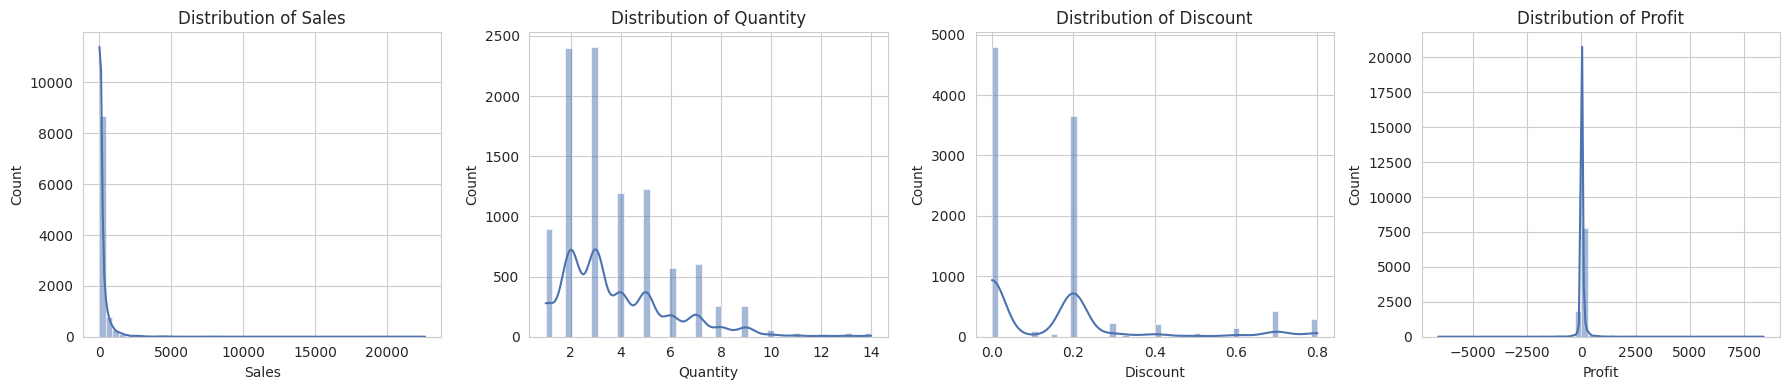

In [5]:
fig, ax = plt.subplots(1,4, figsize=(18,4))
for a,c in zip(ax,num):
    sns.histplot(df[c], bins=50, kde=True, ax=a, color='#4C72B0'); a.set_title(f'Distribution of {c}')
plt.tight_layout(); plt.savefig('figs/01_distributions.png', dpi=200); plt.show()

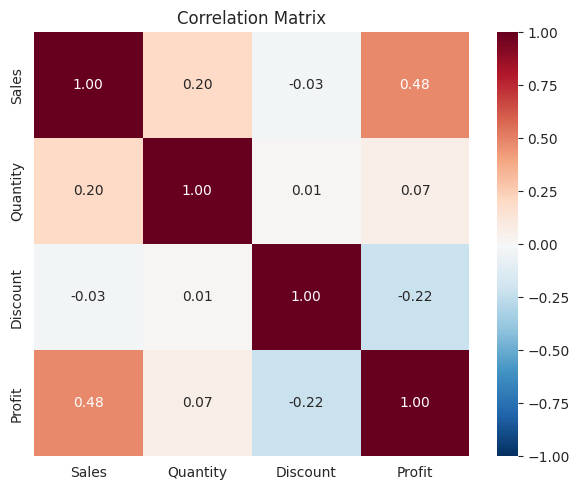

,Sales,Quantity,Discount,Profit
Sales,1.000,0.201,-0.028,0.479
Quantity,0.201,1.000,0.009,0.066
Discount,-0.028,0.009,1.000,-0.219
Profit,0.479,0.066,-0.219,1.000


In [6]:
corr = df[num].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix'); plt.tight_layout(); plt.savefig('figs/02_correlation.png', dpi=200); plt.show()
corr.round(3)

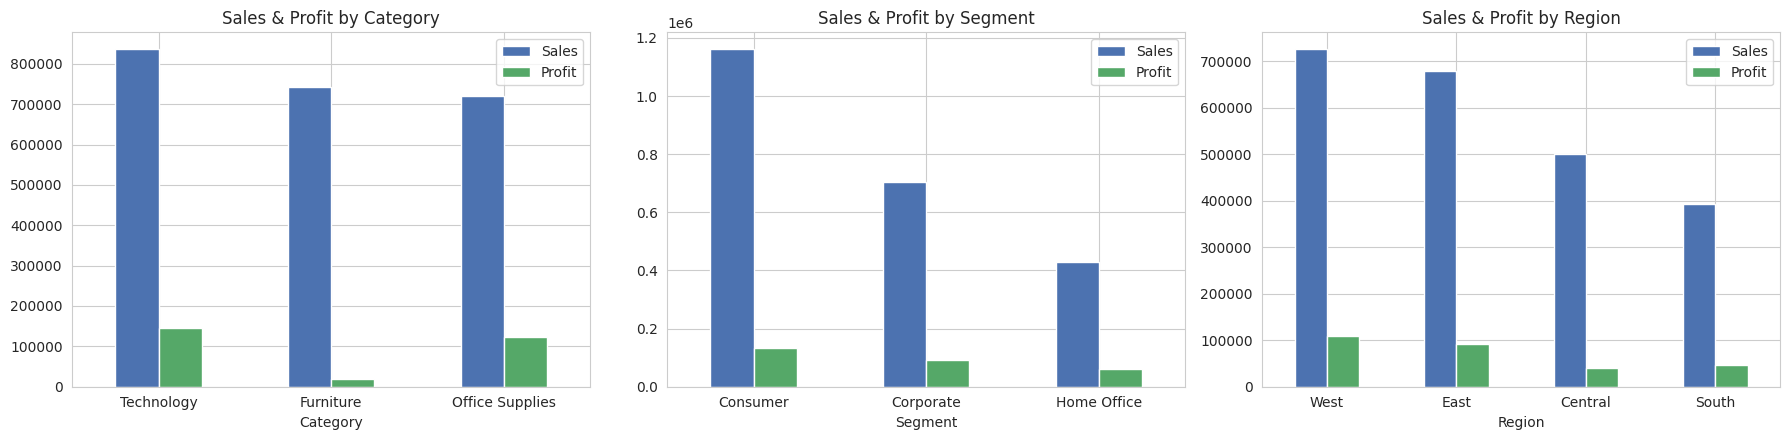

,Sales,Profit,Margin_pct
Category,,,
Furniture,741999.8,18451.3,2.5
Office Supplies,719047.0,122490.8,17.0
Technology,836154.0,145454.9,17.4


In [7]:
fig, ax = plt.subplots(1,3, figsize=(18,4.5))
for a,c in zip(ax,['Category','Segment','Region']):
    g = df.groupby(c)[['Sales','Profit']].sum().sort_values('Sales', ascending=False)
    g.plot(kind='bar', ax=a, color=['#4C72B0','#55A868']); a.set_title(f'Sales & Profit by {c}'); a.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig('figs/03_category_segment_region.png', dpi=200); plt.show()
df.groupby('Category')[['Sales','Profit']].sum().assign(Margin_pct=lambda x: x.Profit/x.Sales*100).round(1)

## 3. Regression Analysis for Feature Selection

### 3a. Multiple Linear Regression (OLS): target = Profit

In [8]:
X = pd.get_dummies(df[['Sales','Quantity','Discount','Category','Segment','Region','Ship Mode']], drop_first=True).astype(float)
y = df['Profit']
Xc = sm.add_constant(X)
ols = sm.OLS(y, Xc).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.280
Method:                 Least Squares   F-statistic:                     299.6
Date:                Tue, 29 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:41:21   Log-Likelihood:                -67066.
No. Observations:                9994   AIC:                         1.342e+05
Df Residuals:                    9980   BIC:                         1.343e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [9]:
vif = pd.DataFrame({'Feature': Xc.columns[1:], 'VIF':[variance_inflation_factor(Xc.values,i) for i in range(1,Xc.shape[1])]})
print(vif.round(2))
coef = pd.DataFrame({'coef':ols.params,'p_value':ols.pvalues}).drop('const').round(4)
coef['significant (p<0.05)'] = coef['p_value']<0.05
coef

                     Feature   VIF
0                      Sales  1.10
1                   Quantity  1.05
2                   Discount  1.07
3   Category_Office Supplies  1.56
4        Category_Technology  1.54
5          Segment_Corporate  1.11
6        Segment_Home Office  1.11
7                Region_East  1.64
8               Region_South  1.45
9                Region_West  1.71
10        Ship Mode_Same Day  1.28
11    Ship Mode_Second Class  1.83
12  Ship Mode_Standard Class  1.97


,coef,p_value,significant (p<0.05)
Sales,0.1845,0.0000,True
Quantity,-3.2057,0.0005,True
Discount,-236.9154,0.0000,True
Category_Office Supplies,50.0899,0.0000,True
Category_Technology,41.0188,0.0000,True
Segment_Corporate,3.0761,0.4996,False
Segment_Home Office,1.4528,0.7902,False
Region_East,-11.8643,0.0356,True
Region_South,-15.1567,0.0198,True
Region_West,-15.5772,0.0052,True


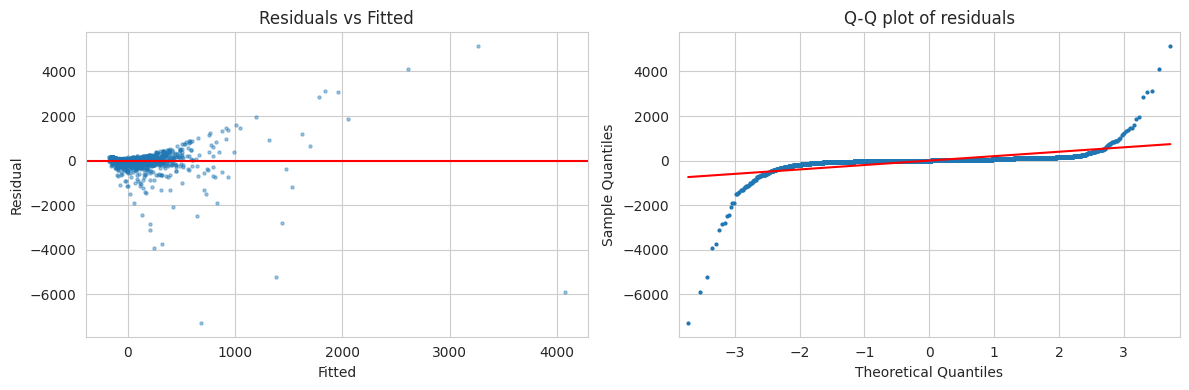

R2 = 0.2807 | Adj R2 = 0.2798 | F-test p = 0.0


In [10]:
# Residual diagnostics
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].scatter(ols.fittedvalues, ols.resid, s=5, alpha=.4); ax[0].axhline(0,color='r'); ax[0].set_title('Residuals vs Fitted'); ax[0].set_xlabel('Fitted'); ax[0].set_ylabel('Residual')
sm.qqplot(ols.resid, line='s', ax=ax[1], markersize=2); ax[1].set_title('Q-Q plot of residuals')
plt.tight_layout(); plt.savefig('figs/04_ols_diagnostics.png', dpi=200); plt.show()
print('R2 =', round(ols.rsquared,4), '| Adj R2 =', round(ols.rsquared_adj,4), '| F-test p =', ols.f_pvalue)

### 3b. Logistic Regression: target = Profitable (1 = profit > 0)

In [11]:
df['Profitable'] = (df['Profit']>0).astype(int)
print(df['Profitable'].value_counts(normalize=True).round(3))
yb = df['Profitable']
Xtr, Xte, ytr, yte = train_test_split(X, yb, test_size=0.25, random_state=42, stratify=yb)
# statsmodels logit for p-values / odds ratios (feature selection)
logit = sm.Logit(ytr, sm.add_constant(Xtr)).fit(disp=0)
res = pd.DataFrame({'coef':logit.params,'odds_ratio':np.exp(logit.params),'p_value':logit.pvalues}).drop('const').round(4)
res['significant (p<0.05)'] = res['p_value']<0.05
print(logit.summary().tables[0]); res

Profitable
1    0.806
0    0.194
Name: proportion, dtype: float64
                           Logit Regression Results                           
Dep. Variable:             Profitable   No. Observations:                 7495
Model:                          Logit   Df Residuals:                     7481
Method:                           MLE   Df Model:                           13
Date:                Tue, 29 Sep 2026   Pseudo R-squ.:                  0.6291
Time:                        14:41:22   Log-Likelihood:                -1366.6
converged:                       True   LL-Null:                       -3684.4
Covariance Type:            nonrobust   LLR p-value:                     0.000


,coef,odds_ratio,p_value,significant (p<0.05)
Sales,-0.0001,0.9999,0.5505,False
Quantity,0.0254,1.0257,0.2931,False
Discount,-18.9692,0.0000,0.0000,True
Category_Office Supplies,1.6969,5.4568,0.0000,True
Category_Technology,1.4194,4.1348,0.0000,True
Segment_Corporate,0.1731,1.1890,0.1323,False
Segment_Home Office,0.0710,1.0736,0.6172,False
Region_East,0.3395,1.4042,0.0164,True
Region_South,0.5285,1.6964,0.0015,True
Region_West,0.5539,1.7401,0.0001,True


Accuracy: 0.9408 | ROC-AUC: 0.954
              precision    recall  f1-score   support

           0       0.98      0.71      0.82       484
           1       0.93      1.00      0.96      2015

    accuracy                           0.94      2499
   macro avg       0.96      0.85      0.89      2499
weighted avg       0.94      0.94      0.94      2499



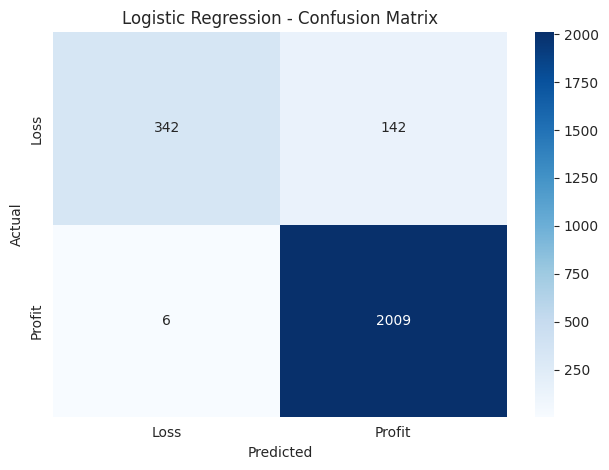

In [12]:
# Predictive performance on test set
lr = LogisticRegression(max_iter=2000).fit(Xtr, ytr)
pred = lr.predict(Xte)
print('Accuracy:', round(accuracy_score(yte,pred),4), '| ROC-AUC:', round(roc_auc_score(yte, lr.predict_proba(Xte)[:,1]),4))
print(classification_report(yte,pred))
cm = confusion_matrix(yte,pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Loss','Profit'], yticklabels=['Loss','Profit'])
plt.title('Logistic Regression - Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.savefig('figs/05_logit_confusion.png', dpi=200); plt.show()

### 3c. Decision Tree (Classification): target = Profitable

Accuracy: 0.9404 | ROC-AUC: 0.9606
              precision    recall  f1-score   support

           0       0.98      0.71      0.82       484
           1       0.93      1.00      0.96      2015

    accuracy                           0.94      2499
   macro avg       0.96      0.85      0.89      2499
weighted avg       0.94      0.94      0.94      2499



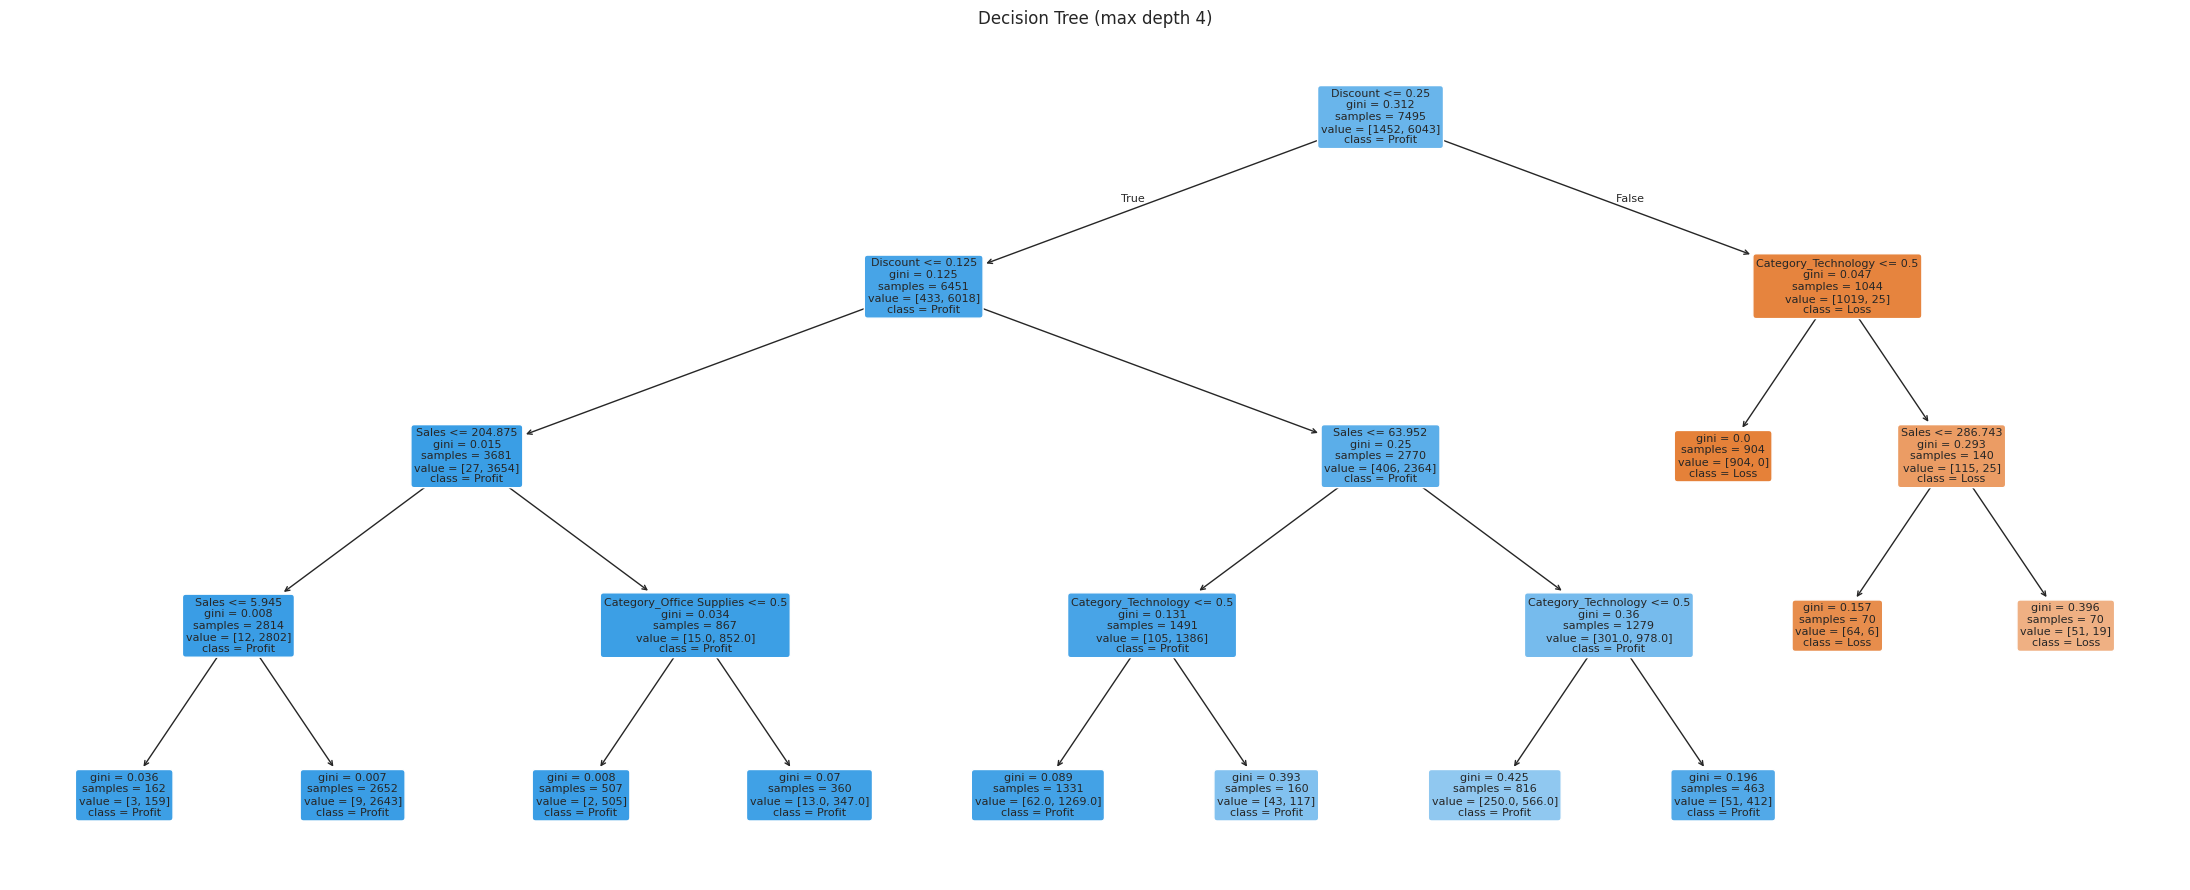

In [13]:
dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, random_state=42).fit(Xtr, ytr)
pd_ = dt.predict(Xte)
print('Accuracy:', round(accuracy_score(yte,pd_),4), '| ROC-AUC:', round(roc_auc_score(yte, dt.predict_proba(Xte)[:,1]),4))
print(classification_report(yte,pd_))
plt.figure(figsize=(22,9))
plot_tree(dt, feature_names=X.columns, class_names=['Loss','Profit'], filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree (max depth 4)'); plt.tight_layout(); plt.savefig('figs/06_decision_tree.png', dpi=200); plt.show()

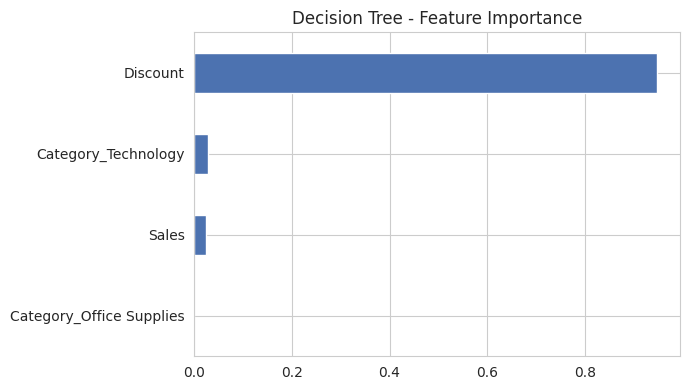

Discount                    0.9478
Category_Technology         0.0273
Sales                       0.0246
Category_Office Supplies    0.0003
Quantity                    0.0000
Segment_Corporate           0.0000
dtype: float64

In [14]:
imp = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)
imp[imp>0].sort_values().plot(kind='barh', color='#4C72B0', figsize=(7,4)); plt.title('Decision Tree - Feature Importance')
plt.tight_layout(); plt.savefig('figs/07_feature_importance.png', dpi=200); plt.show()
imp.head(6).round(4)

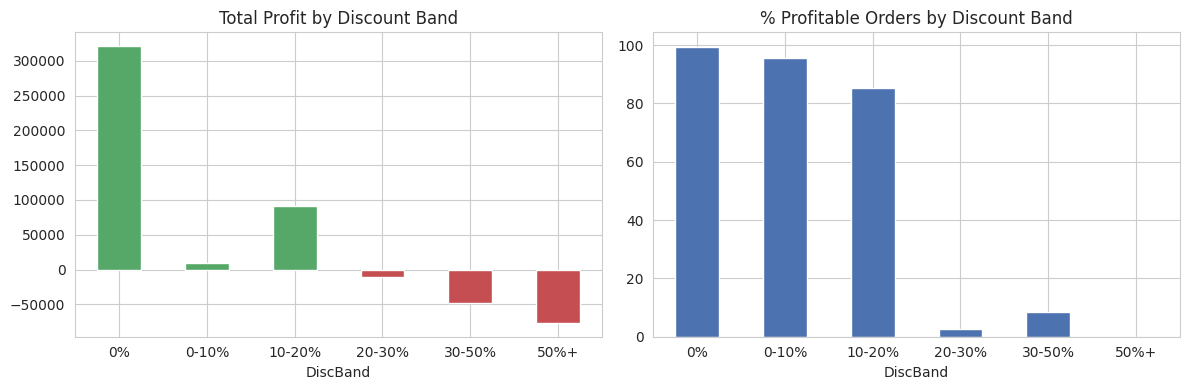

,Orders,Avg_Profit,Total_Profit,Pct_Profitable
DiscBand,,,,
0%,4798,66.90,320987.60,99.4
0-10%,94,96.06,9029.18,95.7
10-20%,3709,24.74,91756.30,85.4
20-30%,227,-45.68,-10369.28,2.6
30-50%,310,-156.28,-48447.73,8.4
50%+,856,-89.44,-76559.05,0.0


In [15]:
# Discount vs profitability - the key business insight
d = df.assign(DiscBand=pd.cut(df['Discount'],[-0.01,0,0.1,0.2,0.3,0.5,0.8],labels=['0%','0-10%','10-20%','20-30%','30-50%','50%+']))
g = d.groupby('DiscBand', observed=True).agg(Orders=('Profit','size'), Avg_Profit=('Profit','mean'), Total_Profit=('Profit','sum'), Pct_Profitable=('Profitable','mean'))
g['Pct_Profitable']=(g['Pct_Profitable']*100).round(1)
fig, ax = plt.subplots(1,2, figsize=(12,4))
g['Total_Profit'].plot(kind='bar', ax=ax[0], color=['#55A868' if v>0 else '#C44E52' for v in g['Total_Profit']]); ax[0].set_title('Total Profit by Discount Band'); ax[0].tick_params(axis='x',rotation=0)
g['Pct_Profitable'].plot(kind='bar', ax=ax[1], color='#4C72B0'); ax[1].set_title('% Profitable Orders by Discount Band'); ax[1].tick_params(axis='x',rotation=0)
plt.tight_layout(); plt.savefig('figs/08_discount_effect.png', dpi=200); plt.show()
g.round(2)

## 4. Time Series Analysis (Monthly Sales)

(48,) 2014-01-01 2017-12-01


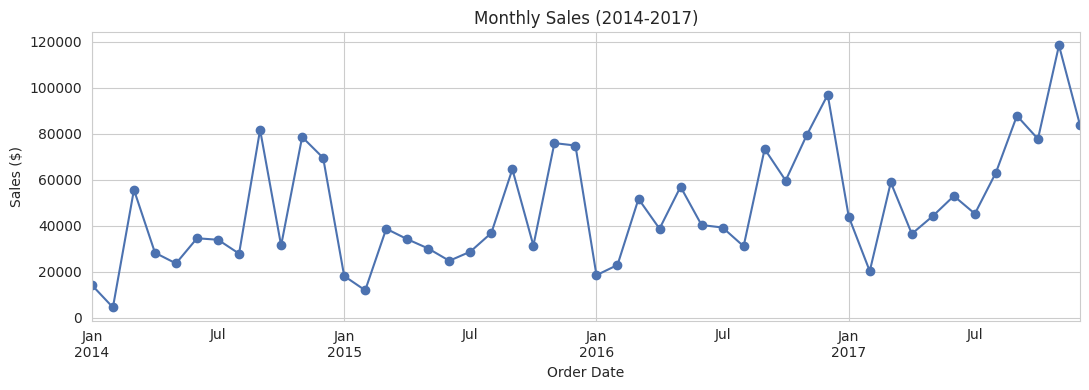

Order Date
2014    484247.0
2015    470533.0
2016    609206.0
2017    733215.0
Name: Sales, dtype: float64


In [16]:
ts = df.set_index('Order Date')['Sales'].resample('MS').sum()
print(ts.shape, ts.index.min().date(), ts.index.max().date())
plt.figure(figsize=(11,4)); ts.plot(marker='o', color='#4C72B0'); plt.title('Monthly Sales (2014-2017)'); plt.ylabel('Sales ($)')
plt.tight_layout(); plt.savefig('figs/09_monthly_sales.png', dpi=200); plt.show()
print(ts.groupby(ts.index.year).sum().round(0))

**Method.** Smoothing parameters (alpha, beta) are chosen on the first 36 months (2014-2016) by minimising one-step-ahead squared error. Each method is then evaluated on the last 12 months (2017) using one-step-ahead forecasts, so all four methods are compared on the same footing.

In [17]:
y = ts.values; n_train = 36

def ses_run(y, a):                      # simple (single) exponential smoothing
    level, f = y[0], [np.nan]
    for v in y[1:]:
        f.append(level); level = a*v + (1-a)*level
    return np.array(f), level

def holt_run(y, a, b):                  # double exponential smoothing (Holt: level + trend)
    level, trend, f = y[0], y[1]-y[0], [np.nan]
    for v in y[1:]:
        f.append(level+trend); new = a*v + (1-a)*(level+trend)
        trend = b*(new-level) + (1-b)*trend; level = new
    return np.array(f), level, trend

def sse(f, lo, hi): return np.sum((y[lo:hi]-f[lo:hi])**2)
grid = np.arange(0.05, 1.0, 0.05)
a_ses = min(grid, key=lambda a: sse(ses_run(y,a)[0], 1, n_train))
a_h, b_h = min(((a,b) for a in grid for b in grid), key=lambda p: sse(holt_run(y,*p)[0], 2, n_train))
print(f'SES alpha = {a_ses:.2f} | Holt alpha = {a_h:.2f}, beta = {b_h:.2f}')

fc = {
 'Moving Average (3-month)': pd.Series(y).rolling(3).mean().shift(1).values,
 'Moving Average (6-month)': pd.Series(y).rolling(6).mean().shift(1).values,
 f'Exponential (alpha={a_ses:.2f})': ses_run(y, a_ses)[0],
 f'Double Exponential (alpha={a_h:.2f}, beta={b_h:.2f})': holt_run(y, a_h, b_h)[0],
}
rows = {}
for k, f in fc.items():
    act, p = y[n_train:], f[n_train:]
    rows[k] = [np.sqrt(np.mean((act-p)**2)), np.mean(np.abs((act-p)/act))*100, np.mean(np.abs(act-p))]
comp = pd.DataFrame(rows, index=['RMSE','MAPE %','MAE']).T.round(1)
comp

SES alpha = 0.30 | Holt alpha = 0.50, beta = 0.15


,RMSE,MAPE %,MAE
Moving Average (3-month),25181.4,43.0,18787.4
Moving Average (6-month),26827.7,44.2,21138.0
Exponential (alpha=0.30),24730.6,40.8,18890.0
"Double Exponential (alpha=0.50, beta=0.15)",26636.8,47.4,21245.5


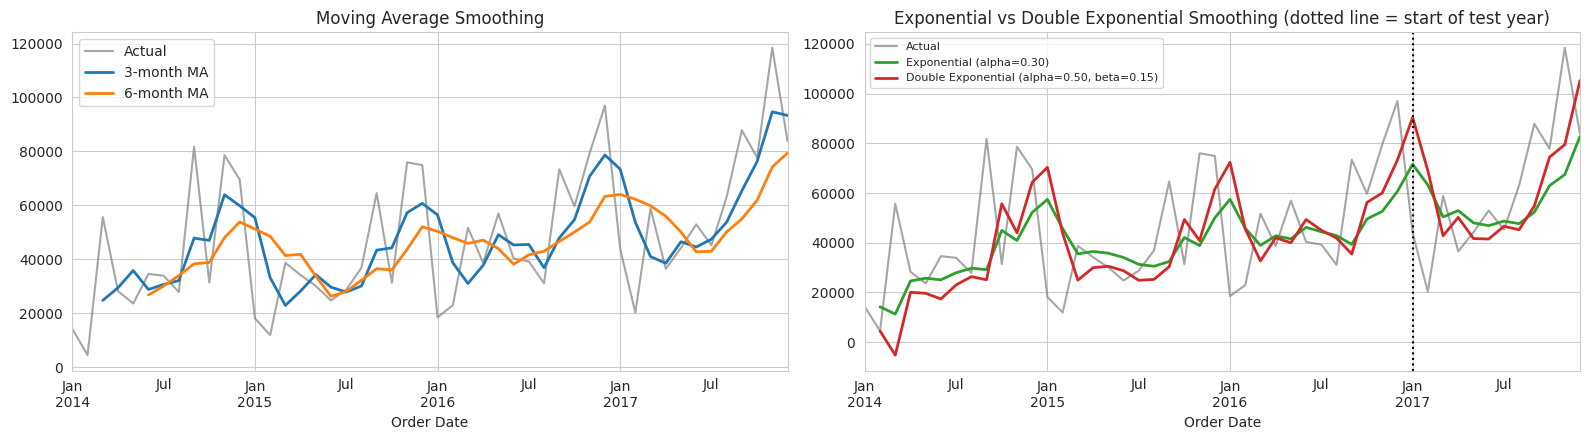

In [18]:
fig, ax = plt.subplots(1,2, figsize=(16,4.5))
ts.plot(ax=ax[0], label='Actual', color='grey', alpha=.7)
ts.rolling(3).mean().plot(ax=ax[0], label='3-month MA', lw=2); ts.rolling(6).mean().plot(ax=ax[0], label='6-month MA', lw=2)
ax[0].set_title('Moving Average Smoothing'); ax[0].legend()
ts.plot(ax=ax[1], label='Actual', color='grey', alpha=.7)
for (name, f), c in zip(list(fc.items())[2:], ['tab:green','tab:red']):
    pd.Series(f, index=ts.index).plot(ax=ax[1], label=name, color=c, lw=2)
ax[1].axvline(ts.index[n_train], color='k', ls=':'); ax[1].set_title('Exponential vs Double Exponential Smoothing (dotted line = start of test year)'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig('figs/10_smoothing_methods.png', dpi=200); plt.show()

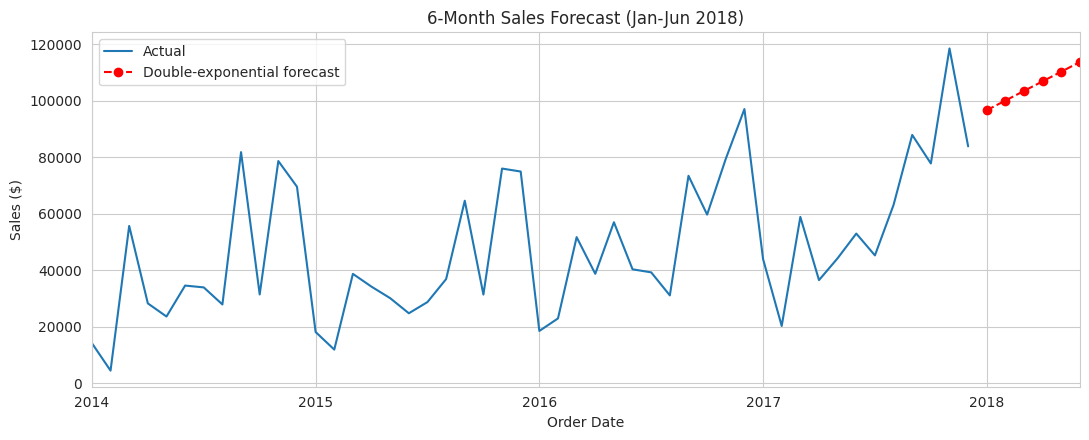

alpha=0.50, beta=0.10


2018-01-01     96609.0
2018-02-01    100019.0
2018-03-01    103428.0
2018-04-01    106837.0
2018-05-01    110246.0
2018-06-01    113656.0
Freq: MS, dtype: float64

In [19]:
# Refit double exponential smoothing on all 48 months and forecast the next 6 months
a2, b2 = min(((a,b) for a in grid for b in grid), key=lambda p: sse(holt_run(y,*p)[0], 2, len(y)))
_, lvl, trd = holt_run(y, a2, b2)
future_idx = pd.date_range(ts.index[-1] + pd.offsets.MonthBegin(), periods=6, freq='MS')
fcast = pd.Series([lvl + (i+1)*trd for i in range(6)], index=future_idx)
plt.figure(figsize=(11,4.5)); ts.plot(label='Actual'); fcast.plot(label='Double-exponential forecast', ls='--', color='red', marker='o')
plt.title('6-Month Sales Forecast (Jan-Jun 2018)'); plt.legend(); plt.ylabel('Sales ($)')
plt.tight_layout(); plt.savefig('figs/11_forecast.png', dpi=200); plt.show()
print(f'alpha={a2:.2f}, beta={b2:.2f}'); fcast.round(0)

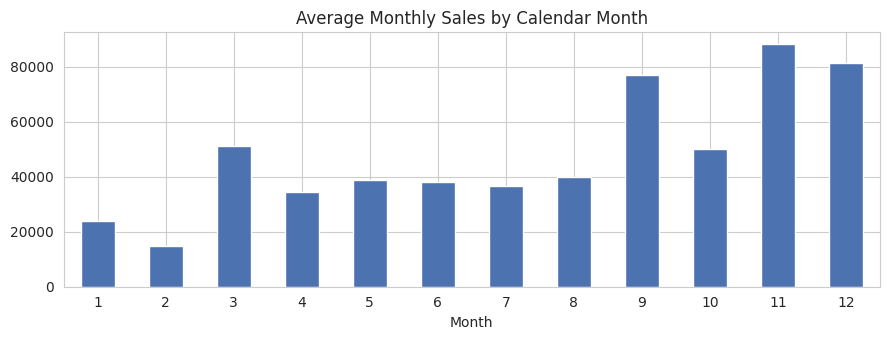

Order Date
1     23731.0
2     14938.0
3     51251.0
4     34441.0
5     38757.0
6     38180.0
7     36810.0
8     39761.0
9     76912.0
10    50081.0
11    88115.0
12    81323.0
Name: Sales, dtype: float64

In [20]:
# Seasonality check (average sales by calendar month)
seas = ts.groupby(ts.index.month).mean()
seas.plot(kind='bar', color='#4C72B0', figsize=(9,3.5)); plt.title('Average Monthly Sales by Calendar Month'); plt.xlabel('Month'); plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig('figs/12_seasonality.png', dpi=200); plt.show()
seas.round(0)

## 5. Conclusion
See the summary of findings in the slides. Add your GitHub / Kaggle profile link here: **<your link>**